---

Reconecte ao Drive.

In [1]:
import os
from pathlib import Path
DRIVE_DIRECTORY = Path.cwd().parent / "data"

---

In [2]:
import pickle

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier
from yellowbrick.classifier import ConfusionMatrix

# Rede neural artificial

Comece recuperando os dados preditores, de treino e de teste, a partir do arquivo `cover_type.pkl` salvo na pasta do Drive. Lembre-se de que você deve instanciar as variáveis `X` e `y`, dos splits `train` e `test`,  na mesma ordem em que salvou.

In [3]:
with open(os.path.join(DRIVE_DIRECTORY, 'cover_type.pkl'), 'rb') as f:
    X_treinamento, y_treinamento, X_teste, y_teste = pickle.load(f)

Instancie e ajuste um classificador do tipo `MLPClassifier`. Altere os valores padrão dos parâmetros, utilizando `verbose=True`, e `hidden_layer_sizes=(100, 50)`.

In [4]:
mlp_classifier = MLPClassifier(
    max_iter=1000, verbose=True, hidden_layer_sizes=(100, 50),
    tol=0.0000100
)
mlp_classifier.fit(X_treinamento, y_treinamento)

Iteration 1, loss = 1.33753420
Iteration 2, loss = 0.90202327
Iteration 3, loss = 0.77300005
Iteration 4, loss = 0.71031352
Iteration 5, loss = 0.66836127
Iteration 6, loss = 0.64250912
Iteration 7, loss = 0.62261884
Iteration 8, loss = 0.60853481
Iteration 9, loss = 0.59835332
Iteration 10, loss = 0.58797595
Iteration 11, loss = 0.57898470
Iteration 12, loss = 0.57215321
Iteration 13, loss = 0.56353364
Iteration 14, loss = 0.55834490
Iteration 15, loss = 0.55256098
Iteration 16, loss = 0.54477628
Iteration 17, loss = 0.54075974
Iteration 18, loss = 0.53448091
Iteration 19, loss = 0.52884074
Iteration 20, loss = 0.52380668
Iteration 21, loss = 0.51810576
Iteration 22, loss = 0.51391233
Iteration 23, loss = 0.50823304
Iteration 24, loss = 0.50661338
Iteration 25, loss = 0.49990150
Iteration 26, loss = 0.49317006
Iteration 27, loss = 0.49052566
Iteration 28, loss = 0.48826000
Iteration 29, loss = 0.47996778
Iteration 30, loss = 0.47644192
Iteration 31, loss = 0.47281955
Iteration 32, los

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


Faça e exiba a predição no split de teste.

In [5]:
previsao = mlp_classifier.predict(X_teste)

In [6]:
previsao

array([4, 4, 5, ..., 6, 6, 2], shape=(2500,))

Calcule a acurácia.

In [7]:
accuracy_score(y_teste, previsao)

0.7808

Exiba a matriz de confusão.

0.7808

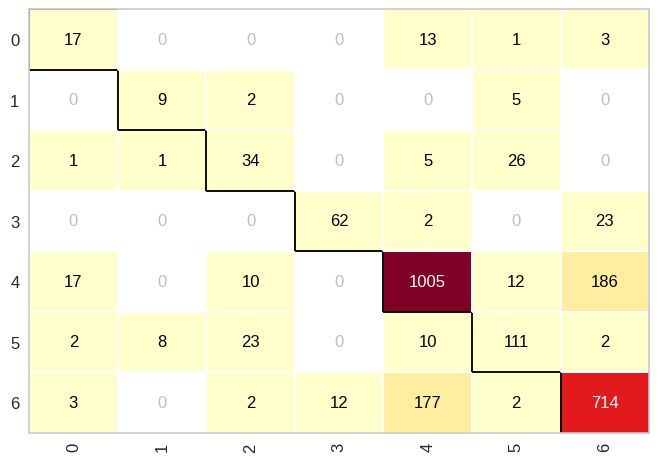

In [8]:
cm = ConfusionMatrix(mlp_classifier, force_model=True)
cm.fit(X_treinamento, y_treinamento)
cm.score(X_teste, y_teste)

Exiba o reporte de classificação.

In [9]:
print(classification_report(y_teste, previsao))

              precision    recall  f1-score   support

           0       0.42      0.50      0.46        34
           1       0.50      0.56      0.53        16
           2       0.48      0.51      0.49        67
           3       0.84      0.71      0.77        87
           4       0.83      0.82      0.82      1230
           5       0.71      0.71      0.71       156
           6       0.77      0.78      0.78       910

    accuracy                           0.78      2500
   macro avg       0.65      0.66      0.65      2500
weighted avg       0.78      0.78      0.78      2500

